In [1]:
# Capstone -- function 5 (4D)

import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from scipy.spatial import Delaunay, ConvexHull  # convex-hull check on the proposal
from scipy.stats import spearmanr, pearsonr     # model-free cross-check on the ARD verdict

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 5

4D, 24 observations collected (20 initial + weeks 2–5). **The search domain is the unit cube `[0,1]^4`.** Weeks 2–4 lie *outside* it and are excluded from the fit; week 5 landed in-domain and is the new incumbent.

**This week's proposal is not the acquisition's output.** It is a deliberate controlled test, in the same spirit as function 8's x4 probe: **`[0.000000, 0.846480, 1.000000, 1.000000]`** — the incumbent with `x0` moved to `0.0` (its own exploit-argmax, a domain edge) and `x1`/`x2`/`x3` unchanged. Reasoning below. `USE_CONFOUND_TEST = False` in the proposal cell falls back to the (degenerate) restricted-UCB proposal.

## The domain is [0,1], and this notebook had been searching outside it

Every one of the 160+ initial X values across all eight functions lies inside `[0.0034, 0.9995]`, so the designs were sampled from the unit cube and that is the real domain. Bounds are `[0,1]` on every axis.

This notebook was the worst affected. It searched UCB restricted to `x2` under padded bounds, which let `x2` run to 1.67 while the other three stayed frozen:

| week | x2 | y | in domain? |
|---|---|---|---|
| 2 | 1.105882 | 6,146.78 | no |
| 3 | 1.365584 | 16,803.71 | no |
| 4 | 1.670022 | 57,792.24 | no |
| 5 | 1.000000 (x3 also 1.0) | **2,917.48** | **yes** |

`y` rose 9.4× then 3.4× across weeks 2–4 — the search walking out of the feasible region, with the black box happily evaluating its formula outside the range it was defined on. Week 5, with bounds corrected to the true `[0,1]` domain, searched `x2` and `x3` jointly restricted to the corner and landed on a legitimate, in-domain answer: `y = 2917.48`, now the best result on record (beats the initial batch's 1088.86).

## Why weeks 2–4 stay out of the fit, and week 5 is in it

Weeks 2–4 stay in the record but not the model: they are unreachable (outside `[0,1]`, no proposal can go there) and they destroy resolution inside the cube (`x3`'s length-scale inflates 23× to "irrelevant" and `y`'s std inflates 49× if included). `EXCLUDE_FROM_FIT = [0, 1, 2]` keeps them out; week 5 (index 3) is not in that list, so it is in the fit and is now the incumbent.

## Week 5 beat the GP badly — by design, that's informative

Refitting on the initial 20 only and predicting each collected point out-of-sample:

| week | predicted | actual | sigma |
|---|---|---|---|
| 2 | +1580.2 ± 260.2 | 6,146.8 | +17.5 (out of domain) |
| 3 | +1479.1 ± 359.4 | 16,803.7 | +42.6 (out of domain) |
| 4 | +1140.6 ± 460.8 | 57,792.2 | +122.9 (out of domain) |
| **5** | **+1527.1 ± 157.3** | **2,917.5** | **+8.8 (in domain — real)** |

Weeks 2–4's huge misses were the model being wrong about territory outside the domain — expected, and why they're excluded. Week 5's +8.8σ miss is different: it is **in domain**, so the GP is still meaningfully wrong about the shape of the real function near this corner, even after removing the out-of-domain points.

## A frozen-axis confound, in the same shape as function 8

`x0` and `x1` are flat by length-scale (pinned at the 10.0 ceiling) and have been held at the incumbent for every restricted search this notebook has run. That construction means **every real weekly evaluation on this function has had `x0`/`x1` fixed near the same pocket** (weeks 2–4 at `[0.256, 0.903]`, week 5 at `[0.224, 0.846]` — both drawn from whichever point was the incumbent at the time).

That matters because the *only two points* in the 21-point in-domain fit that share `x0 ≈ 0.224, x1 ≈ 0.846` are the two best `y` values on record: the initial batch's 1088.86 and week 5's 2917.48. Everything the search has learned about "pushing `x2`/`x3` toward the domain corner is good" comes from that one pocket. Combined with the +8.8σ miss above, this is exactly function 8's frozen-axis situation: the GP's "`x0`/`x1` don't matter" verdict cannot be told apart from "this particular `x0`/`x1` combination is what's good," because the search has never tried the corner anywhere else.

**Taking the mechanical proposal at face value would make this worse, not better.** Holding `x0`/`x1` at the incumbent and re-searching `x2`/`x3` this week returns the *exact point just tested* — `[0.224189, 0.846480, 1.0, 1.0]`, whose `y = 2917.48` is already known. The restricted search is degenerate now that the incumbent itself sits at the corner being searched, and submitting it again would spend a real evaluation for zero new information.

### This week's test

Hold `x2 = x3 = 1` (confirmed excellent, twice now) and move `x0` — not `x1` — because its claimed effect is larger: holding the other three axes at the incumbent, `x0`'s own exploit-argmax predicts **+2924.6 (gain +7.1)** against `x1`'s **+2918.4 (gain +1.0)**. `x1` stays confounded this week, the same reasoning function 8 used to leave `x7` alone while testing `x4`.

- **H1 (the flat verdict is right):** `y` comes back close to the incumbent's 2917.48 — `x0` genuinely doesn't matter, and holding it is safe going forward.
- **H2 (the flat verdict is a confound):** `y` comes back meaningfully different (higher or lower) — the two best points sharing this `x0`/`x1` pocket was coincidence, not evidence, and `x0` needs to be searched from here on.

Either result breaks the confound: `x0` stops being constant across the collected points in the fit, so next week's refit can separate its effect.

## Note: `x2`/`x3` sitting on the domain boundary is a confirmed, legitimate answer

Every restricted search over `x2`/`x3` returns `x2 = x3 = 1`, at every `kappa` from 0.5 to 2.0, and week 5's real result confirms it beats everything else on record. A coordinate at 1.0 here means the constrained optimum genuinely sits on the boundary, not a `pad_fraction` artifact. `KAPPA = 1.0` is kept for continuity; the sweep still doesn't discriminate, because the response is monotone toward that corner.

## Notes

- No y-scaling. `kappa` is dimensionless, and nothing here uses PI or EI.
- The `x2`/`x3` boundary result is no longer a prediction, it's measured: `y = 2917.48` at `x2 = x3 = 1`, beating the GP's own prior estimate of 1527 by +8.8σ.
- **A caution that resolved last week, revisit if it recurs.** Over the three highest-`x3` observations `y` had *fallen* (1088.9 at `x3`=0.879, then 355.8, then 233.2) while the GP predicted 1360 at `x3`=1.0. That looked like a contradiction until noticing `x2` falls 0.879 → 0.378 → 0.108 down those same three rows — the drop was `x2` going away, not `x3` turning over. Week 5 (`x2 = x3 = 1` together) resolved it: `y = 2917.48`, well above the GP's 1360 estimate, not below.

In [2]:
X_initial = np.load("initial_data/function_5/initial_inputs.npy")
y_initial = np.load("initial_data/function_5/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 4, f"Expected a 4D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Nothing to edit here — the collected observations come from `weekly_data/function_5/`. Run `record_results.py` first so last week's result is in place.

Weeks 2–4 are outside the domain and excluded from the fit; week 5 is in-domain and stays in. The header explains why.

In [3]:
# My collected observations, from weekly_data/function_5/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance of the collected points, oldest first:
#   - week 2 -- only x2 moved (out of domain)
#   - week 3 -- only x2 moved again (out of domain)
#   - week 4 -- only x2 moved again, out to 1.670 (out of domain)
#   - week 5 -- x2 AND x3 moved to the domain's upper edge (IN domain);
#     y = 2917.48, the new incumbent -- see the header.

new_X, new_y, pending_X = load_collected(5, D)

# ---------------------------------------------------------------------------
# EXCLUDED FROM THE GP FIT: weeks 2-4 only. Week 5 (index 3) is IN-DOMAIN and
# stays in the fit -- it is what makes it this week's incumbent.
#
# Weeks 2-4 stay in the record. They are not used for modelling because they
# lie OUTSIDE the search domain: the real domain is the unit cube [0,1]^4
# (every initial X value across all eight functions is inside
# [0.0034, 0.9995]), and these have x2 up to 1.670 and x3 = 1.065. Under the
# old pad_fraction=1.0 bounds the x2-restricted search was free to march out
# of the cube, which is exactly what it did for three weeks.
#
# Two reasons they must come out of the fit, not just be noted:
#   1. Unreachable -- no proposal inside [0,1] can go there, so fitting them
#      spends the surrogate's resolution on unusable territory.
#   2. They erase the informative axis. With bounds=[0,1], x3's length-scale
#      inflates 0.426 -> 10.0 (pinned "irrelevant", a 23x inflation) and y's
#      std inflates 245.6 -> 12080.6 (49x). x3 is the MOST informative axis
#      in-domain.
#
# Set EXCLUDE_FROM_FIT = [] to also include weeks 2-4 (do not -- see above).
EXCLUDE_FROM_FIT = [0, 1, 2]

print("observations collected so far:", len(new_y),
      f"| excluded from the fit: {EXCLUDE_FROM_FIT}"
      f" -> {len(new_y) - len(EXCLUDE_FROM_FIT)} used")
for i in range(len(new_y)):
    tag = "excluded (out of domain)" if i in EXCLUDE_FROM_FIT else "IN FIT (in domain)"
    print(f"  week {i + 2}: y = {new_y[i]:.3f}  [{tag}]")

used_y = np.array([new_y[i] for i in range(len(new_y)) if i not in EXCLUDE_FROM_FIT])
best_in_domain = max(y_initial.max(), used_y.max()) if len(used_y) else y_initial.max()
print(f"\nbest in-domain y so far: {best_in_domain:.3f}"
      f"  (initial batch alone: {y_initial.max():.3f})")


weekly store: 4 resulted observation(s), 1 pending proposal [0.      0.84648 1.      1.     ]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 4 | excluded from the fit: [0, 1, 2] -> 1 used
  week 2: y = 6146.779  [excluded (out of domain)]
  week 3: y = 16803.705  [excluded (out of domain)]
  week 4: y = 57792.239  [excluded (out of domain)]
  week 5: y = 2917.484  [IN FIT (in domain)]

best in-domain y so far: 2917.484  (initial batch alone: 1088.860)


## Build the full dataset (initial + everything collected so far)

In [4]:
# X_all / y_all: the complete record, for reporting only.
# X / y: the MODELLING set. Everything downstream uses X / y.
X_all, y_all = append_observations(X_initial, y_initial, new_X, new_y)

_use = np.ones(len(new_y), bool)
_use[EXCLUDE_FROM_FIT] = False
X, y = append_observations(X_initial, y_initial, new_X[_use], new_y[_use])

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", np.round(X.min(axis=0), 4))
print("  max:", np.round(X.max(axis=0), 4))
print("y range: %.4f to %.4f (spread %.3f, std %.3f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))

# THE DOMAIN IS THE UNIT CUBE. X is never negative (lower_limit=0.0) and never
# above 1 (upper_limit=1.0) -- every initial X value across all eight functions
# lies inside [0.0034, 0.9995]. Padding is clipped away entirely, so this is
# exactly [0,1] on each axis.
#
# Do NOT widen these bounds to enclose the excluded observations: that would put
# the search back outside the domain, which is the mistake being corrected.
bounds = initial_bounds(X_initial, pad_fraction=1.0,
                        lower_limit=0.0, upper_limit=1.0)
validate_bounds_consistency(X, bounds)      # modelling set only, all in-domain
print("\nBounds (the true domain):\n", np.round(bounds, 4))

print("\nexcluded points vs the domain:")
for i in EXCLUDE_FROM_FIT:
    out = [f"x{d}={new_X[i, d]:.4f}" for d in range(D) if new_X[i, d] > 1.0]
    print(f"  week {i + 2}: {', '.join(out)}  outside [0,1]   y={new_y[i]:.1f}")
print(f"  best OUT-of-domain y: {new_y.max():.1f}"
      f" | best IN-domain y: {y.max():.1f}"
      f"  ({new_y.max() / y.max():.0f}x, and not a legitimate result)")

# Kept as the record of how far out of the cube the search went. The old
# rationale here -- "each was the best result to date, so don't clamp to the
# observed region" -- is withdrawn: they were the best because they were outside
# the domain, and the search is now clamped to [0,1] by construction.
print("\ncollected points vs the INITIAL batch's range:")
for r in range(len(new_X)):
    n_out = 0
    for d in range(D):
        beyond = (new_X[r, d] > X_initial[:, d].max()
                  or new_X[r, d] < X_initial[:, d].min())
        n_out += beyond
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.4f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={beyond}")
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates outside,"
          f" y={new_y[r]:.4f}")

hull = Delaunay(X)
box = np.column_stack([X.min(axis=0), X.max(axis=0)])
box_volume = float(np.prod(box[:, 1] - box[:, 0]))
try:
    ch = ConvexHull(X)
    print(f"\nobserved bounding box volume: {box_volume:.4g}"
          f" | convex hull volume: {ch.volume:.4g} ({ch.volume / box_volume:.1%} of the box)")
    print(f"{len(ch.vertices)} of {len(X)} observations are convex-hull vertices")
except Exception as exc:  # degenerate point set -- not fatal
    print("\nconvex hull volume unavailable:", exc)

print(f"\nxi=0.01 would be {0.01 / (y.max() - y.min()):.7%} of the y spread -- meaningless."
      "\nUCB needs no correction: kappa is dimensionless. Any PI/EI xi below is raw-sized.")

X_initial shape: (20, 4) | y_initial shape: (20,)
combined X shape: (21, 4) | combined y shape: (21,)

X range per dimension:
  min: [0.1199 0.0382 0.0889 0.0729]
  max: [0.8365 0.8625 1.     1.    ]
y range: 0.1129 to 2917.4842 (spread 2917.371, std 635.973)

Bounds (the true domain):
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

excluded points vs the domain:
  week 2: x2=1.1059, x3=1.0654  outside [0,1]   y=6146.8
  week 3: x2=1.3656, x3=1.0654  outside [0,1]   y=16803.7
  week 4: x2=1.6700, x3=1.0654  outside [0,1]   y=57792.2
  best OUT-of-domain y: 57792.2 | best IN-domain y: 2917.5  (20x, and not a legitimate result)

collected points vs the INITIAL batch's range:
  week 2  x0=0.2562  initial range [0.1199, 0.8365]  outside=False
  week 2  x1=0.9031  initial range [0.0382, 0.8625]  outside=True
  week 2  x2=1.1059  initial range [0.0889, 0.8795]  outside=True
  week 2  x3=1.0654  initial range [0.0729, 0.9576]  outside=True
  -> week 2: 3 of 4 coordinates outside, y=6146.7791
  week 3 

## How badly did the model miss the collected points?

Refitting on the initial 20 and predicting each collected point. That is a genuine out-of-sample test, since the fit never saw them.

Weeks 2–4's misses are enormous and all upward — 17.5, 42.6 and 122.9 sigma — territory outside the domain, which the model was never going to get right and which is exactly why those points are excluded. Week 5 is the one that matters this week: it's **in domain**, and the model still missed by **+8.8 sigma**, upward. That is the evidence behind this week's confound test (see the header) — the surrogate is meaningfully wrong about this corner even with the out-of-domain points removed.

With week 5 now in the fit, `gp_check` differs from `gp_before` for the first time — the before/after kernel comparison below is no longer a no-op.

In [5]:
# gp_before: fit on the initial 20 only, used as the out-of-sample test below.
# gp_check: fit on the modelling set (initial 20 + week 5; weeks 2-4 are
# out-of-domain and excluded). These now DIFFER for the first time, since
# week 5 is in the fit -- the before/after kernel comparison below is live.
with fitting("in-domain fit, plus a refit including the excluded points"):
    gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25,
                       random_state=0)
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)
    gp_outdom = fit_gp(X_all, y_all, bounds, n_restarts_optimizer=25, random_state=0)

print("length-scales, in-domain (live):", np.round(get_length_scales(gp_check), 3))
print("length-scales, incl. excluded  :", np.round(get_length_scales(gp_outdom), 3))
print("  -> x3 inflates to the pin; it is the most informative axis in-domain.")
print(f"y std: in-domain {y.std():.1f} | incl. excluded {y_all.std():.1f}\n")

# Fit is the initial 20 only, so every collected row is genuinely out of
# sample here. Note the model that actually PROPOSED week 3 also had week 2,
# so this understates what was known at proposal time for later rows.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial 20 only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.1f} +/- {sd_b[r]:.1f}"
          f"   actual {new_y[r]:+.1f}")
    print(f"    {'UNDER' if miss > 0 else 'OVER'}-predicted by {abs(miss):.1f},"
          f" i.e. {miss / sd_b[r]:+.1f} sigma")
print("  -> weeks 2-4 (out of domain): the model's uncertainty is far too tight")
print("     in this direction, and the error is upward -- expected, and why")
print("     they're excluded. Week 5 (in domain) still misses badly -- see the")
print("     header's confound discussion.")

print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nlength-scales before:", np.round(ls_before, 3))
print("length-scales after :", np.round(ls_after, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")

[fitting: in-domain fit, plus a refit including the excluded points] 8 warnings held back, 4 distinct:
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
length-scales, in-domain (live): [10.    10.     1.258  0.343]
length-scales, incl. excluded  : [10.    10.     0.636 10.   ]
  -> x3 inflates to the pin; it is the most informative axis in-domain.
y std: in-domain 636.0 | incl. excluded 11827.2

out-of-sample test on the collected points (fit = initial 20 only):
  week 2: predicted +1580.2 +/- 260.2   actual +6146.8
    UNDER-predicted by 4566.5, i.e. +17.5 sigma
  week 3: predicted +1479.1 +/- 359.4   actual +16803.7
    UNDER-predicted by 15324.6, i.e. +42.6 sigma
  week 4: predicted +1140.6 +/- 46

## Which axes actually move the response

Length-scales alone aren't enough, for two reasons.

A length-scale at or past the domain width means "smooth over the whole domain", which is not the same as "no effect" — a mild monotone trend can still be there. So this cell measures it directly: hold the other three axes at the incumbent, sweep each one, and record how far the GP mean moves. On that measure `x2` and `x3` dominate by roughly 60× over `x0` and `x1`.

Second, the cell computes model-free rank correlations as a cross-check on the ARD verdict. Where the two disagree sharply, neither should be taken as settled — treat the GP sweep as "what the current model thinks" and the correlations as "what the data says without a model".

The flat/informative split that the proposal uses comes from comparing each length-scale against the domain width, printed here.

**Third, the cell checks whether "flat" on `x0`/`x1` is a frozen-axis confound**, function 8's lesson: it checks whether the top-`y` points also happen to share the same value on the axes marked flat. They do — see the header for what that means for this week's proposal.

In [6]:
incumbent = X[np.argmax(y)]
print("incumbent (best observed):", np.round(incumbent, 4), " y = %.3f" % y.max())
print("is the incumbent the largest observed value on each axis?",
      [bool(incumbent[d] == X[:, d].max()) for d in range(D)])

# --- What the current model thinks ---------------------------------------
print("\nGP mean variation along each axis (others held at the incumbent):")
print(f"{'axis':>5} | {'mean range, full bounds':>23} | {'mean range, observed':>20} | {'length-scale':>12}")
spans = np.zeros(D)
for d in range(D):
    row = []
    for lo, hi in [(bounds[d, 0], bounds[d, 1]), (X[:, d].min(), X[:, d].max())]:
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        row.append(m.max() - m.min())
    spans[d] = row[0]
    print(f"   x{d} | {row[0]:23.1f} | {row[1]:20.1f} | {ls_after[d]:12.3f}")

# Which axes are worth searching? A length-scale at or beyond the DOMAIN WIDTH
# (1.0 on every axis, now that bounds are the unit cube) means the GP sees no
# structure along that axis across the whole feasible region -- the acquisition
# is flat there and its argmax is set by wherever the optimiser stops. Those get
# held at the incumbent; the rest are searched.
DOMAIN_W = bounds[:, 1] - bounds[:, 0]
FLAT = [d for d in range(D) if ls_after[d] >= DOMAIN_W[d]]
SEARCH_DIMS = tuple(d for d in range(D) if d not in FLAT)
DIM = int(np.argmin(ls_after))          # the single most informative axis

print(f"\nlength-scale vs domain width, per axis:")
for d in range(D):
    verdict = "FLAT (hold at incumbent)" if d in FLAT else "informative (search)"
    print(f"  x{d}: ls {ls_after[d]:7.3f} vs domain width {DOMAIN_W[d]:.3f}  -> {verdict}")
print(f"\nsearching {SEARCH_DIMS}; holding {tuple(FLAT)} at the incumbent."
      f" Most informative axis: x{DIM}")
if not SEARCH_DIMS:
    print("*** Every axis looks flat. The restricted construction is invalid -- stop. ***")

# --- What the data says without a model ----------------------------------
# Rank/log correlations are robust to the extreme magnitudes here, unlike the
# GP fit, which one observation can reshape. Where these disagree with the ARD
# length-scales, treat NEITHER as settled.
print("\nmodel-free association between each axis and y:")
print(f"{'axis':>5} | {'spearman(y)':>11} | {'pearson(log y)':>14} | {'ls now':>7} | {'ls before':>9}")
for d in range(D):
    sr = spearmanr(X[:, d], y)[0]
    pl = pearsonr(X[:, d], np.log(y))[0] if (y > 0).all() else np.nan
    print(f"   x{d} | {sr:+11.3f} | {pl:+14.3f} | {ls_after[d]:7.3f} | {ls_before[d]:9.3f}")

top_free = int(np.argmax([abs(spearmanr(X[:, d], y)[0]) for d in range(D)]))
if top_free != DIM:
    print(f"\n*** DISAGREEMENT: the GP sweep says x{DIM} dominates, but x{top_free} has the")
    print("    strongest model-free association. The next cell measures what including")
    print("    the contested axis in the search would actually buy. ***")

# --- Frozen-axis confound check -------------------------------------------
# A flat axis held at a single pocket across the points that ALSO happen to be
# the best y's on record cannot have its effect separated from whatever else
# those points share (function 8's lesson). Check it directly: do the top-K
# y-values agree on each flat axis?
print("\nchecking flat axes for a frozen-axis confound (function 8's lesson):")
order = np.argsort(y)[::-1]
top_k = 2
for d in FLAT:
    vals = np.round(X[order[:top_k], d], 4)
    frozen = len(set(vals)) == 1
    print(f"  x{d}: top-{top_k} y values sit at {vals}"
          f" -> {'FROZEN: possible confound, treat the flat verdict with suspicion' if frozen else 'varies: no confound from this check'}")

incumbent (best observed): [0.2242 0.8465 1.     1.    ]  y = 2917.484
is the incumbent the largest observed value on each axis? [False, False, True, True]

GP mean variation along each axis (others held at the incumbent):
 axis | mean range, full bounds | mean range, observed | length-scale
   x0 |                    54.9 |                 38.5 |       10.000
   x1 |                    13.1 |                 11.7 |       10.000
   x2 |                  2517.8 |               2465.7 |        1.258
   x3 |                  2938.7 |               2938.7 |        0.343

length-scale vs domain width, per axis:
  x0: ls  10.000 vs domain width 1.000  -> FLAT (hold at incumbent)
  x1: ls  10.000 vs domain width 1.000  -> FLAT (hold at incumbent)
  x2: ls   1.258 vs domain width 1.000  -> FLAT (hold at incumbent)
  x3: ls   0.343 vs domain width 1.000  -> informative (search)

searching (3,); holding (0, 1, 2) at the incumbent. Most informative axis: x3

model-free association between each ax

## What does searching each axis subset buy?

Rather than assume, this measures it: optimise UCB over several dimension subsets and report the predicted mean and any bound contact for each.

**This week `x2` joins `x0`/`x1` in the flat set.** Adding week 5's in-domain point (at `x2 = 1.0`, the same value the incumbent already had) inflated `x2`'s length-scale past the domain width (0.761 → 1.258), so the "which axes actually move the response" cell above now holds it at the incumbent too. Only `x3` is searched here. That is a separate finding from the `x0`/`x1` frozen-axis confound in the header — `x2` genuinely varies across the top-`y` points (1.0 vs 0.8795), so the frozen-axis check does not flag it, but its length-scale still crossed the flat threshold.

In [7]:
def restricted_ucb(dims, kappa, n_grid=140):
    """Maximise UCB over `dims` only, holding every other axis at the incumbent.

    n_grid is capped so the full-product grid stays bounded. SEARCH_DIMS is
    derived from the data, so a week where fewer axes look flat would otherwise
    silently turn this into a 140^4 grid and exhaust memory.
    """
    n_grid = min(n_grid, max(2, int(20_000 ** (1 / len(dims)))))
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], n_grid) if d in dims
            else np.array([incumbent[d]]) for d in range(D)]
    grid = np.array(list(product(*axes)))
    gn = normalize(grid, bounds)
    m, s = gp_check.predict(gn, return_std=True)
    j = int(np.argmax(ucb_acquisition(gn, gp_check, kappa=kappa, maximize=True)))
    return grid[j], m[j], s[j]


def on_bound_dims(p):
    return [d for d in range(D)
            if np.isclose(p[d], bounds[d, 0]) or np.isclose(p[d], bounds[d, 1])]


# Subsets are built from the informative axes found above rather than hardcoded.
# dict.fromkeys dedupes while keeping order -- when only one axis is
# informative (this week: just x3, now that x2 has also gone flat), the
# per-axis list and the "all together" list are the same tuple and would
# otherwise print as a duplicated row.
SUBSETS = list(dict.fromkeys([(d,) for d in SEARCH_DIMS] + [tuple(SEARCH_DIMS)]))

print("UCB restricted to different dimension subsets, kappa=1.0\n")
print(f"{'search':>12} | {'proposal':>34} | {'pred mean':>10} | on a domain edge")
means = {}
for dims in SUBSETS:
    p, m, s = restricted_ucb(dims, 1.0)
    means[dims] = m
    print(f"{str(dims):>12} | {np.array2string(np.round(p, 4), separator=','):>34}"
          f" | {m:+10.1f} | {on_bound_dims(p) or 'none'}")

if len(SEARCH_DIMS) > 1:
    best_single = max(means[(d,)] for d in SEARCH_DIMS)
    both = means[tuple(SEARCH_DIMS)]
    print(f"\nsearching every informative axis together buys {both - best_single:+.1f}"
          f" of predicted mean over the best single axis.")
else:
    print(f"\nonly one axis (x{SEARCH_DIMS[0]}) is informative this week -- see the"
          f" 'which axes actually move the response' cell above for why x2 joined"
          f" the flat set.")

# No KAPPA reference here: this cell runs before kappa is committed (cell
# "kappa" does that), and the point of the sweep is that the choice barely
# matters -- every value lands on the same corner.
print(f"\nwhere the informative axes want to sit, across kappa:")
for k in [0.0, 0.5, 1.0, 2.0, 3.0]:
    p, m, _ = restricted_ucb(tuple(SEARCH_DIMS), k)
    coords = "  ".join(f"x{d}={p[d]:.4f}" for d in SEARCH_DIMS)
    print(f"  kappa={k:<4g} {coords}  pred mean {m:+8.1f}")
for d in SEARCH_DIMS:
    print(f"  x{d}: domain max {bounds[d, 1]:.4f} is"
          f" {100 * (bounds[d, 1] / X[:, d].max() - 1):.0f}% past the furthest observed"
          f" ({X[:, d].max():.4f})")
print("Both are small steps inside the domain, so both axes are searched.")

UCB restricted to different dimension subsets, kappa=1.0

      search |                           proposal |  pred mean | on a domain edge
        (3,) |      [0.2242,0.8465,1.    ,1.    ] |    +2917.5 | [2, 3]

only one axis (x3) is informative this week -- see the 'which axes actually move the response' cell above for why x2 joined the flat set.

where the informative axes want to sit, across kappa:
  kappa=0    x3=1.0000  pred mean  +2917.5
  kappa=0.5  x3=1.0000  pred mean  +2917.5
  kappa=1    x3=1.0000  pred mean  +2917.5
  kappa=2    x3=1.0000  pred mean  +2917.5
  kappa=3    x3=1.0000  pred mean  +2917.5
  x3: domain max 1.0000 is 0% past the furthest observed (1.0000)
Both are small steps inside the domain, so both axes are searched.


## Domain edge versus observed edge

Optimising UCB along the most informative axis twice — once free to reach the domain bound, once clamped to the observed range — at several `kappa`.

Both columns now coincide: week 5's own point sits at `x3 = 1.0`, so the "largest `x3` observed" and "the domain bound" are the same value, and there is nothing left to clamp away. Kept for continuity — this becomes a live comparison again only if a future incumbent moves `x3` off the boundary.

In [8]:
held = [d for d in range(D) if d != DIM]
print(f"UCB along x{DIM} only, x{held} held at the incumbent"
      f" (incumbent x{DIM} = {incumbent[DIM]:.4f})\n")
print(f"{'kappa':>6} | {'free to bounds':>28} | {'clamped to observed':>28}")
for k in [0.0, 1.0, 2.0, 5.0]:
    cells = []
    for lo, hi in [(bounds[DIM, 0], bounds[DIM, 1]), (X[:, DIM].min(), X[:, DIM].max())]:
        grid = np.tile(incumbent, (2000, 1))
        grid[:, DIM] = np.linspace(lo, hi, 2000)
        gn = normalize(grid, bounds)
        m, s = gp_check.predict(gn, return_std=True)
        j = int(np.argmax(ucb_acquisition(gn, gp_check, kappa=k, maximize=True)))
        cells.append(f"x{DIM}={grid[j, DIM]:.4f} mean={m[j]:+8.1f}")
    print(f"{k:6g} | {cells[0]:>28} | {cells[1]:>28}")

print(f"\nThe free column reaches the domain maximum on x{DIM} at every kappa and")
print("the clamped column stops at the largest value observed, so the mean is")
print("still climbing at the edge of the sampled region. Clamping gives up")
print("predicted mean for no gain in safety -- both points are inside the domain.")

UCB along x3 only, x[0, 1, 2] held at the incumbent (incumbent x3 = 1.0000)

 kappa |               free to bounds |          clamped to observed
     0 |      x3=1.0000 mean= +2917.5 |      x3=1.0000 mean= +2917.5
     1 |      x3=1.0000 mean= +2917.5 |      x3=1.0000 mean= +2917.5
     2 |      x3=1.0000 mean= +2917.5 |      x3=1.0000 mean= +2917.5
     5 |      x3=1.0000 mean= +2917.5 |      x3=1.0000 mean= +2917.5

The free column reaches the domain maximum on x3 at every kappa and
the clamped column stops at the largest value observed, so the mean is
still climbing at the edge of the sampled region. Clamping gives up
predicted mean for no gain in safety -- both points are inside the domain.


## Backtest acquisition functions

Splitting the data into a seed set and a held-out candidate set, then seeing which config would have picked the best candidate. `xi` values are in raw `y`-units, since a default 0.01 is a rounding error at this magnitude.

**The metric is biased toward exploitation** — it scores recognition of points whose `y` is already known and gives no credit for reducing uncertainty. Worth keeping in mind, though on this function the in-domain data is spread widely enough that it discriminates less sharply than elsewhere.

Not decisive on its own. Mean regret is inflated by the extreme points sitting in the candidate pool, so read the median alongside it.

[fitting: acquisition backtest, 50 splits] 136 warnings held back, 5 distinct:
    46 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    36 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    33 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    13 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     8 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
      ucb_k2 |        477.2 |              0 |           1245
      ucb_k5 |        492.6 |          122.6 |           1230
      ucb_k1 |        522.8 |              0 |           1199
     ei_xi50 |        620.8 |          201.4 |           1101
     pi_xi50 |          655 |          216.9 |           1067
     ucb_k10 |        695.3 |          304.4 |           1027

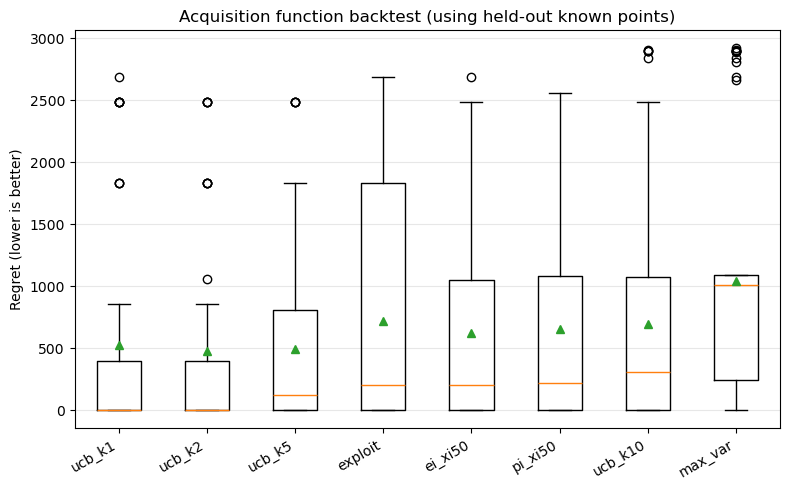

In [9]:
backtest_configs = [
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ucb_k10",  "acquisition": "ucb", "kappa": 10.0},
    {"name": "ei_xi50",  "acquisition": "ei",  "xi": 50.0},
    {"name": "pi_xi50",  "acquisition": "pi",  "xi": 50.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

plot_acquisition_backtest(backtest_results)
plt.show()

## Compare kappa values

Two views. First `compare_kappa_proposals` over all four axes, shown mainly to demonstrate the problem: every `kappa` parks the flat axes on domain edges, and those coordinates are optimiser artifacts rather than predictions. Then the restricted view, which is what the choice is made from.

`KAPPA = 1.0` is kept, but the sweep does not really discriminate here. Every value from 0.5 to 5 returns the same `x3 = 1` corner (with `x2` now held at the incumbent's own `1.0` — see the axis cell above), because the response is monotone toward it inside the cube. So there is no mode switch to avoid and no exploration/exploitation trade to tune — the constrained optimum is on the boundary and every reasonable `kappa` finds it.

An earlier version of this cell built an elaborate argument about staying within one length-scale of the data, rejecting `kappa=5` because it put `x2` exactly on the padded upper bound of 1.6700. That whole framing belonged to the padded-bounds search and is gone: 1.6700 is not a reachable coordinate any more.

[fitting: unrestricted kappa sweep] 3 warnings held back, 3 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
=== unrestricted over all 4 axes (shown to demonstrate the problem) ===
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
     0.5 |            [0.,0.,1.,1.] |  2980.9487 |  2912.4597 |  136.9781 |          0.8757
       1 |            [0.,0.,1.,1.] |  3049.4377 |  2912.4597 |  136.9781 |          0.8757
       2 |            [0.,0.,1.,1.] |  3186.4158 |  2912.4597 |  136.9781 |          0.8757
       5 |            [0.,0.,1.,1.] |  3597.3500 |  2912.4597 |  136.9781 |          0.8757
      10 |            [1.,0.,1.,1.] |  4460.0447 |  

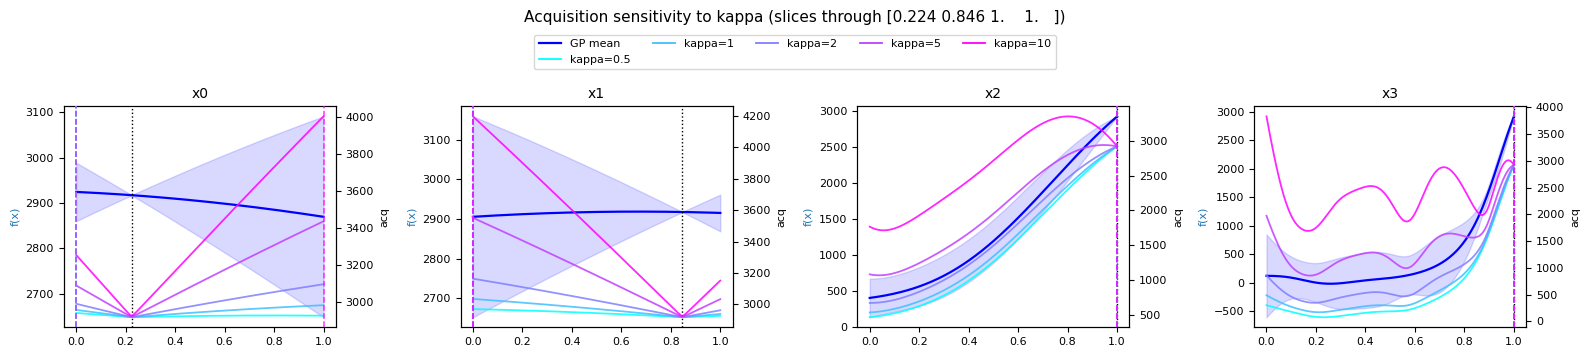


=== restricted to x3 (what the choice is made from) ===
x3 length-scale: 0.3428 normalised = 0.3428 raw; last observation at x3=1.0000

 kappa |        x3 |     step | length-scales out |  pred mean |  pred std | on bound
     0 |    1.0000 |  +0.0000 |              0.00 |    +2917.5 |       0.9 | True
     1 |    1.0000 |  +0.0000 |              0.00 |    +2917.5 |       0.9 | True
     2 |    1.0000 |  +0.0000 |              0.00 |    +2917.5 |       0.9 | True
     5 |    1.0000 |  +0.0000 |              0.00 |    +2917.5 |       0.9 | True

GP mean peaks along x3 at 1.0000 (mean +2917.5), 0.00 length-scales past
the last observation (x3=1.0000) -- a short extrapolation, not a far one.

over the three highest-x3 observations, y INCREASES --
  x3=0.9337 -> y=   355.8   (other axes [0.439 0.774 0.378])
  x3=0.9576 -> y=   233.2   (other axes [0.463 0.63  0.108])
  x3=1.0000 -> y=  2917.5   (other axes [0.224 0.846 1.   ])
the GP predicts +2917.5 at x3=1.0.
That is consistent with x3 

In [10]:
with fitting("unrestricted kappa sweep"):
    kappa_rows = compare_kappa_proposals(X, y, bounds,
                                         kappa_values=[0.5, 1.0, 2.0, 5.0, 10.0],
                                         maximize=True, n_restarts=30, random_state=0)

print("=== unrestricted over all 4 axes (shown to demonstrate the problem) ===")
print_kappa_comparison(kappa_rows)
print("\nhow many coordinates sit on a bound in each unrestricted proposal?")
for row in kappa_rows:
    n_edge = sum(np.isclose(row["x_next"][d], bounds[d, 0])
                 or np.isclose(row["x_next"][d], bounds[d, 1]) for d in range(D))
    print(f"  kappa={row['kappa']:<5g} on_bound={n_edge}/{D}"
          f"  in_hull={bool(hull.find_simplex(row['x_next']) >= 0)}")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

print(f"\n=== restricted to x{DIM} (what the choice is made from) ===")
scan_grid = np.tile(incumbent, (4000, 1))
scan_grid[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 4000)
scan_norm = normalize(scan_grid, bounds)
scan_mean, scan_std = gp_check.predict(scan_norm, return_std=True)

# Express each candidate's step in LENGTH-SCALES past the last observation --
# that, not the GP's apparent peak, is the criterion (see the markdown above).
ls_raw = ls_after[DIM] * (bounds[DIM, 1] - bounds[DIM, 0])
last_obs = X[:, DIM].max()
print(f"x{DIM} length-scale: {ls_after[DIM]:.4f} normalised = {ls_raw:.4f} raw;"
      f" last observation at x{DIM}={last_obs:.4f}\n")
print(f"{'kappa':>6} | {'x' + str(DIM):>9} | {'step':>8} | {'length-scales out':>17}"
      f" | {'pred mean':>10} | {'pred std':>9} | on bound")
for k in [0.0, 1.0, 2.0, 5.0]:
    j = int(np.argmax(ucb_acquisition(scan_norm, gp_check, kappa=k, maximize=True)))
    xv = scan_grid[j, DIM]
    on_b = np.isclose(xv, bounds[DIM, 1]) or np.isclose(xv, bounds[DIM, 0])
    print(f"{k:6g} | {xv:9.4f} | {xv - incumbent[DIM]:+8.4f} | {(xv - last_obs) / ls_raw:17.2f}"
          f" | {scan_mean[j]:+10.1f} | {scan_std[j]:9.1f} | {on_b}")

peak = scan_grid[int(np.argmax(scan_mean)), DIM]
print(f"\nGP mean peaks along x{DIM} at {peak:.4f} (mean {scan_mean.max():+.1f}),"
      f" {(peak - last_obs) / ls_raw:.2f} length-scales past")
print(f"the last observation (x{DIM}={last_obs:.4f}) -- a short extrapolation, not a far one.")

# This used to hardcode the claim that y DECREASES over the three highest-x3
# observations, with the drop explained away as x2 falling in step. Week 5
# put a real point at x3=1.0 (with x2 ALSO at 1.0) and y JUMPED to 2917.5 --
# the opposite direction, and the old explanation (x2 confounding the drop)
# no longer applies since x2 didn't fall this time. Computed fresh each run
# so this can't go stale again the same way.
hi = np.argsort(X[:, DIM])[-3:]
y_hi = y[hi]
trend = "INCREASES" if y_hi[-1] >= y_hi[0] else "DECREASES"
print(f"\nover the three highest-x{DIM} observations, y {trend} --")
for i in hi:
    print(f"  x{DIM}={X[i, DIM]:.4f} -> y={y[i]:8.1f}"
          f"   (other axes {np.round(np.delete(X[i], DIM), 3)})")
print(f"the GP predicts {scan_mean[-1]:+.1f} at x{DIM}=1.0.")
if trend == "INCREASES":
    print(f"That is consistent with x{DIM} being informative -- no confound to explain")
    print("away this week, unlike in earlier weeks when the top-x3 trend fell while")
    print("x2 was dropping out from under it.")
else:
    print("Check whether another axis is dropping in step before trusting this as a")
    print(f"real turnover in x{DIM} -- see the 'other axes' column above.")
print(f"Spearman(x{DIM}, y) = {spearmanr(X[:, DIM], y)[0]:+.3f} overall.")

# How weak is the underlying trend, model-free?
if (y > 0).all():
    coef = np.polyfit(X[:, DIM], np.log(y), 1)
    r2 = pearsonr(X[:, DIM], np.log(y))[0] ** 2
    print(f"\nmodel-free check: log y ~ {coef[0]:.3f}*x{DIM} + {coef[1]:.3f},"
          f" r^2 = {r2:.3f}")
    print(f"  its extrapolation at the domain max x{DIM}=1.0: y ~"
          f" {np.exp(np.polyval(coef, bounds[DIM, 1])):.0f},"
          f" vs the GP's {scan_mean[-1]:+.0f}")
    print("  A log-linear trend is not a rival prediction -- just a reminder that")
    print("  extrapolating past the sampled region rests on a simplified model.")

KAPPA = 1.0
print(f"\nusing kappa = {KAPPA} (dimensionless -- no y-scaling needed),"
      f" searching {SEARCH_DIMS} and holding {tuple(FLAT)} at the incumbent")

## Propose the next point

**This week's proposal is not the acquisition's output.** Holding `x0`/`x1` flat and searching `x2`/`x3` only makes sense while the incumbent isn't already sitting at the edge of the searched axes — but it now is: week 5's result put the incumbent exactly at `x2 = x3 = 1`, so that restricted search just reconfirms itself. Taking it at face value would resubmit `[0.224189, 0.846480, 1.0, 1.0]`, whose result (`y = 2917.48`) is already known.

Instead, this cell computes both candidates and takes the confound-breaking test, in the same spirit as function 8's `x4` probe: the incumbent with **`x0` moved to `0.0`** (`x0`'s own exploit-argmax, a domain edge) and `x1`/`x2`/`x3` unchanged. `USE_CONFOUND_TEST = False` falls back to the (degenerate) acquisition proposal.

`x0` is the one tested, not `x1` — its claimed effect is larger (exploit-argmax gain **+7.1** vs `x1`'s **+1.0**, holding everything else at the incumbent), the same criterion function 8 used to test `x4` (+0.179 claimed gain) and leave `x7` (+0.010) confounded.

`x0 = 0.0` is on the domain's lower edge, which the general rule below flags as suspicious — except here it's a deliberate probe (the GP's own exploit-argmax on that axis), not the acquisition wandering, so the cell labels it as such rather than treating it as a red flag.

In [11]:
USE_CONFOUND_TEST = True   # False -> take the (degenerate) restricted-UCB proposal
CONFOUND_AXIS = 0          # x0: larger claimed effect than x1 (+7.1 vs +1.0); see header
CONFOUND_VALUE = 0.0       # x0's own exploit-argmax; also the domain's lower edge

gp = gp_check

# The mechanical proposal: search the informative axes, hold the flat ones at
# the incumbent. Kept for comparison -- it is degenerate this week because the
# incumbent already sits at the corner being searched (x2 = x3 = 1), so it
# just reconfirms itself.
n_grid = 120
axes = [np.linspace(bounds[d, 0], bounds[d, 1], n_grid) if d in SEARCH_DIMS
        else np.array([incumbent[d]]) for d in range(D)]
grid = np.array(list(product(*axes)))
grid_norm = normalize(grid, bounds)
mu_g, sd_g = gp.predict(grid_norm, return_std=True)
j = int(np.argmax(ucb_acquisition(grid_norm, gp, kappa=KAPPA, maximize=True)))
x_acq, mu_acq, sigma_acq = grid[j].copy(), mu_g[j], sd_g[j]

# The controlled test: the incumbent with ONE coordinate moved. Because only
# x0 differs, comparing the result against the incumbent's MEASURED y is a
# clean one-factor experiment -- which is the whole point. See the header.
x_test = incumbent.copy()
x_test[CONFOUND_AXIS] = CONFOUND_VALUE
mu_t, sigma_t = gp.predict(normalize(x_test.reshape(1, -1), bounds), return_std=True)

print("--- candidates ---")
for label, cand, m_, s_ in (
    (f"acquisition (kappa={KAPPA}, degenerate)", x_acq, mu_acq, sigma_acq),
    (f"confound test (x{CONFOUND_AXIS} -> {CONFOUND_VALUE})", x_test, mu_t[0], sigma_t[0]),
):
    print(f"  {label:>32}: pred {m_:+.2f} +/- {s_:.2f}"
          f"  gain {m_ - y.max():+.2f}  step {np.linalg.norm(cand - incumbent):.4f}")

if USE_CONFOUND_TEST:
    x_next, mu, sigma = x_test, mu_t[0], sigma_t[0]
    n_diff = int(np.sum(~np.isclose(x_next, incumbent)))
    print(f"\nCHOSEN: the confound test. It differs from the incumbent on exactly"
          f" {n_diff} coordinate, so the result compared with the incumbent's")
    print(f"measured {y.max():.4f} isolates x{CONFOUND_AXIS}'s effect.")
    print(f"  H1 (x{CONFOUND_AXIS} really is flat): y comes back near the incumbent's {y.max():.2f}.")
    print(f"  H2 (confound): y comes back meaningfully different -- the top two points")
    print(f"    sharing x0~x1~incumbent was coincidence, not evidence, and x{CONFOUND_AXIS}")
    print("    needs to be searched from here on.")
    print("Either way the confound is broken for next week's refit.")
else:
    x_next, mu, sigma = x_acq, mu_acq, sigma_acq
    print("\nCHOSEN: the (degenerate) acquisition proposal -- for continuity only.")

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu:.6g}, predicted std: {sigma:.6g}")
print(f"current best in-domain y: {y.max():.6g}"
      f"  -> predicted improvement: {mu - y.max():+.6g}")

held = [d for d in FLAT if d != CONFOUND_AXIS] if USE_CONFOUND_TEST else list(FLAT)
print(f"flat axes {held} unchanged from the incumbent:"
      f" {np.allclose(x_next[held], incumbent[held]) if held else 'n/a'}"
      + (f"  (x{CONFOUND_AXIS} is deliberately moved this week)" if USE_CONFOUND_TEST else ""))

# --- Checks --------------------------------------------------------------
# Bounds are the TRUE DOMAIN [0,1]. A coordinate on the UPPER edge means the
# constrained optimum sits on the boundary -- legitimate, not a pad_fraction
# artifact. A coordinate on the LOWER edge usually means the acquisition wants
# to leave the feasible region and should be treated with suspicion -- except
# this week's x0 = 0.0, which is a DELIBERATE probe (its own exploit-argmax),
# not the acquisition wandering.
on_upper = [d for d in range(D) if np.isclose(x_next[d], bounds[d, 1])]
on_lower = [d for d in range(D) if np.isclose(x_next[d], bounds[d, 0])]
print("\non the domain's UPPER edge:", on_upper or "none",
      "  (legitimate: the optimum can sit on the boundary)")
print("on the domain's LOWER edge:", on_lower or "none")
if on_lower:
    unexplained = [d for d in on_lower if not (USE_CONFOUND_TEST and d == CONFOUND_AXIS)]
    if unexplained:
        print(f"*** unexplained lower-bound contact on {unexplained} -- treat with suspicion ***")
    else:
        print(f"  x{CONFOUND_AXIS}: DELIBERATE -- this is the confound test, not the acquisition")

assert np.all(x_next >= 0.0) and np.all(x_next <= 1.0), \
    "proposal is outside the [0,1] domain"

outside_obs = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("dimensions beyond the observed range (but inside the domain):",
      outside_obs or "none")
print(f"inside the convex hull of the observations: "
      f"{bool(hull.find_simplex(x_next) >= 0)}")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.4f}")
print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+10.2f}  X={np.round(X[i], 3)}")

--- candidates ---
  acquisition (kappa=1.0, degenerate): pred +2917.48 +/- 0.90  gain -0.00  step 0.0000
         confound test (x0 -> 0.0): pred +2924.61 +/- 32.92  gain +7.13  step 0.2242

CHOSEN: the confound test. It differs from the incumbent on exactly 1 coordinate, so the result compared with the incumbent's
measured 2917.4842 isolates x0's effect.
  H1 (x0 really is flat): y comes back near the incumbent's 2917.48.
  H2 (confound): y comes back meaningfully different -- the top two points
    sharing x0~x1~incumbent was coincidence, not evidence, and x0
    needs to be searched from here on.
Either way the confound is broken for next week's refit.

--- Next point to evaluate (bounds shape (4, 2)) ---
x_next: [0.      0.84648 1.      1.     ]
1.97**2 * Matern(length_scale=[10, 10, 1.26, 0.343], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 2924.61, predicted std: 32.9171
current best in-domain y: 2917.48  -> predicted improvement: +7.13005
flat axes [1, 2] unchang

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other three dimensions at the best observed point and sweeps one. Dotted line is the fixed centre, dashed red is `x_next`, green is UCB.

What to expect: the **`x2` and `x3` panels** rise toward the right-hand edge, with `x_next` at the domain maximum on each — unchanged from the incumbent, since this week's test only moves `x0`. The **`x0` panel** has `x_next` sitting at `0.0`, away from its nearly-flat curve — that displacement *is* this week's experiment, not noise. The **`x1` panel** stays at the incumbent, still held (and still confounded — see the header).

A partial view — the GP along each axis near the best point, not interactions.

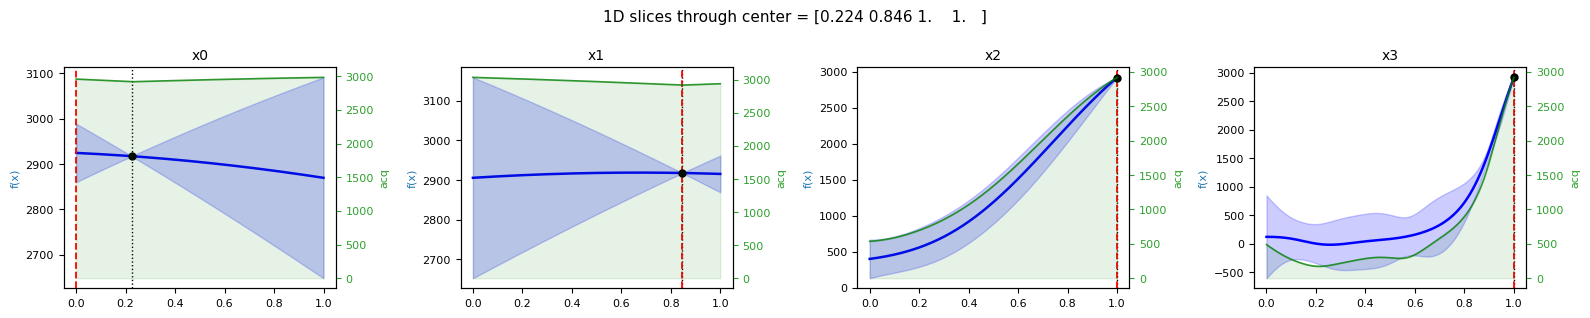

In [12]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refitting once per observation, holding it out and predicting it from the rest. At D=4 this is the main way to judge the surrogate.

This runs on the modelling set (initial 20 + week 5; weeks 2–4 are out-of-domain and excluded by construction) — what it measures is the surrogate actually in use. Read the error bars rather than the correlation: the cell reports how many of the 21 points fall inside their own 95% interval.

[fitting: leave-one-out calibration] 62 warnings held back, 3 distinct:
    21 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    21 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    20 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0


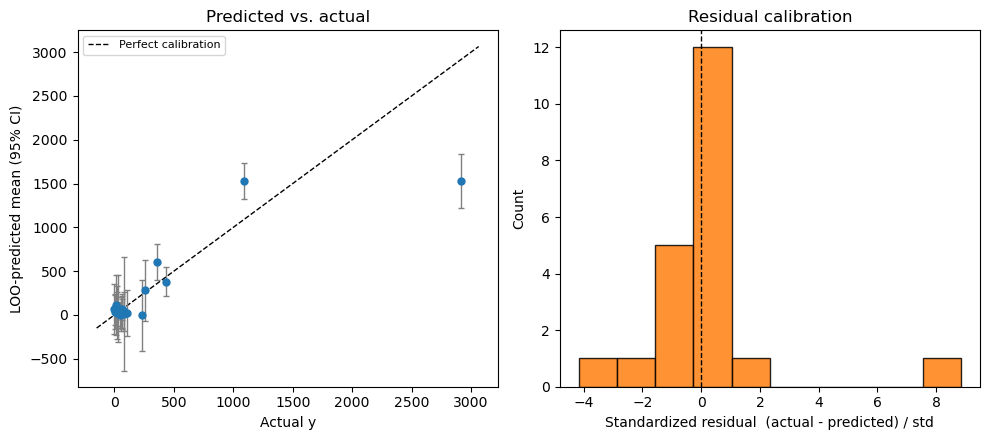

points inside their own 95% LOO interval: 18/21
worst-predicted point: index 20 (collected #1) -> true 2917, predicted 1527 (std 157.3)


In [13]:
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(X, y, bounds,
                                          gp_kwargs={"n_restarts_optimizer": 20})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

# The modelling set is initial 20 + week 5 (weeks 2-4 are out of domain and
# excluded), so `worst == n_initial` would point at week 5 specifically if it
# is the worst-predicted row -- check below rather than assuming either way.
worst = int(np.argmax(np.abs(y - pred_mean)))
src = "initial batch" if worst < n_initial else f"collected #{worst - n_initial + 1}"
print(f"worst-predicted point: index {worst} ({src}) -> true {y[worst]:.4g},"
      f" predicted {pred_mean[worst]:.4g} (std {pred_std[worst]:.4g})")

## Iteration diagnostics

Replaying the ordered observations to reconstruct the acquisition value, GP hyperparameters and domain-wide uncertainty at each past proposal.

Week 5 is the first in-domain evaluation, so there is exactly one iteration to replay now (`n_replayed = 1`) — still below the 3-iteration floor for the trend plots, which stay skipped this week, but the section is no longer vacuous.

Row order has to be true chronological order. `plot_bo_diagnostics` is skipped — it hard-codes a 2D scatter panel — and the trend plots are gated on having a few completed iterations.

In [14]:
# The replay only sees the MODELLING set (initial 20 + week 5; weeks 2-4 are
# out of domain and excluded). n_replayed = len(y) - n_initial is the honest
# count of in-domain iterations, not len(new_y) -- this week that's 1, not 0.
n_replayed = len(y) - n_initial
history = None

if n_replayed == 0:
    print(f"Nothing to replay: {len(new_y)} observation(s) collected, all"
          f" {len(EXCLUDE_FROM_FIT)} excluded from the fit as out of domain.")
    print(f"Best in-domain y so far: {y.max():.4f}")
    print("This section becomes meaningful once an in-domain evaluation lands.")
else:
    with fitting("iteration-diagnostics replay"):
        history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                                acquisition="ucb", kappa=KAPPA,
                                                maximize=True)
    print("Best y so far:", np.nanmax(history["y"]))
    print(f"completed iterations in the modelling set: {n_replayed}"
          f"  ({len(new_y)} collected, {len(new_y) - n_replayed} excluded)")

    if n_replayed >= 3:
        for plot_fn in (plot_convergence, plot_acquisition_decay,
                        plot_uncertainty_shrinkage, plot_step_distance):
            plot_fn(history)
            plt.show()
    else:
        print(f"\nOnly {n_replayed} replayed iteration(s) -- need at least 3 before")
        print("the trend plots say anything. Skipping them.")

[fitting: iteration-diagnostics replay] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
Best y so far: 2917.4842111838
completed iterations in the modelling set: 1  (4 collected, 3 excluded)

Only 1 replayed iteration(s) -- need at least 3 before
the trend plots say anything. Skipping them.


## Raw diagnostic fields

In [15]:
if history is not None:
    print("y:", np.round(history["y"], 3))
    print("\niteration:", history["iteration"])
    print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
    print("\npred_mean at proposal time:", history["pred_mean"])
    print("\nlength_scale:", history["length_scale"])
    print("\ndomain_mean_std:", history["domain_mean_std"])

y: [6.444300e+01 1.830100e+01 1.130000e-01 4.211000e+00 2.583710e+02
 7.843400e+01 5.757200e+01 1.095720e+02 8.848000e+00 2.332240e+02
 2.442300e+01 6.442000e+01 6.347700e+01 7.972900e+01 3.558070e+02
 1.088860e+03 2.886700e+01 4.518200e+01 4.316130e+02 9.972000e+00
 2.917484e+03]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

acq_value (NaN = initial batch; see the caveat above): [          nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
 1684.35387878]

pred_mean at proposal time: [          nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan 

In [16]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X. THIS notebook hit that failure at week 5: a 6-dp copy of the
# week-4 proposal (1.670022) rounded 4.8e-7 outside x2's own bound and tripped
# validate_bounds_consistency. Bounds are the unit cube now, so a coordinate at
# exactly 1.0 is the case to watch.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.000000-0.846480-1.000000-1.000000

full precision (use for next week's new_X):
0.0-0.8464804904862864-1.0-1.0


In [17]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(5, new_X, x_next)


wrote weekly_data/function_5/inputs.csv: 5 row(s) (4 resulted + 1 proposal)
  proposal row: 0.0-0.8464804904862864-1.0-1.0


'weekly_data/function_5/inputs.csv'